# Malware Detection: Exploratory Data Analysis

## 📚 Libraries Used:
* **Pandas & NumPy**: Core data structures and numerical computing.
* **Matplotlib & Seaborn**: Scientific data visualization.
* **Scikit-Learn**: Specifically `mutual_info_classif` for estimating mutual information for a discrete target variable.

## Exploratory Data Analysis (EDA)
> We aim to introduce the dataset, analyze the distribution of these classes and the statistical characteristics of the features

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Set up the style for the plots
plt.style.use('fivethirtyeight')
sns.set_palette("husl")
%matplotlib inline

# --- 1. LOAD DATA ---
df = pd.read_csv("../data/malware_data_final.csv")

### 📋 Dataset Objectives:
* **Structure Audit:** Identify how many features are numeric vs. categorical using `df.info()`.
* **Statistical Distribution:** Use `df.describe()` to check for outliers or features with zero variance (which provide no predictive value).
* **Integrity Check:** Ensure the dataset loaded correctly and matches the expected dimensions.

In [ ]:
# Print the summary of the data
print("--- GENERAL INFORMATION ---")
print(df.info())
print("\n--- DESCRIPTION OF NUMERICAL DATA ---")
display(df.describe())

--- GENERAL INFORMATION ---
<class 'pandas.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MD5                 7045 non-null   str    
 1   Sections            7045 non-null   int64  
 2   AvgEntropy          7045 non-null   float64
 3   MaxEntropy          7045 non-null   float64
 4   SuspiciousSections  7045 non-null   int64  
 5   DLLs                7045 non-null   int64  
 6   Imports             7045 non-null   int64  
 7   HasSensitiveAPI     7045 non-null   int64  
 8   ImageBase           7045 non-null   uint64 
 9   SizeOfImage         7045 non-null   int64  
 10  HasVersionInfo      7045 non-null   int64  
 11  Label               7045 non-null   int64  
dtypes: float64(2), int64(8), str(1), uint64(1)
memory usage: 880.8 KB
None

--- DESCRIPTION OF NUMERICAL DATA ---


,Sections,AvgEntropy,MaxEntropy,SuspiciousSections,DLLs,Imports,HasSensitiveAPI,ImageBase,SizeOfImage,HasVersionInfo,Label
count,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7.045000e+03,7.045000e+03,7045.000000,7045.000000
mean,5.764940,4.114946,6.812340,0.063165,9.842583,118.712420,0.431086,2.618417e+15,5.932257e+05,0.553584,0.591199
std,2.072738,1.603267,1.121516,0.254681,12.338867,141.867253,0.495263,2.197754e+17,4.705867e+06,0.497156,0.491647
min,1.000000,0.369700,1.046400,0.000000,0.000000,0.000000,0.000000,0.000000e+00,8.192000e+03,0.000000,0.000000
25%,4.000000,2.846000,6.128800,0.000000,3.000000,39.000000,0.000000,4.194304e+06,1.351680e+05,0.000000,0.000000
50%,5.000000,4.132000,6.677800,0.000000,4.000000,76.000000,0.000000,4.194304e+06,2.744320e+05,1.000000,1.000000
75%,8.000000,5.388800,7.840100,0.000000,10.000000,141.000000,1.000000,5.368709e+09,8.232960e+05,1.000000,1.000000
max,20.000000,7.999700,7.999700,4.000000,120.000000,3425.000000,1.000000,1.844674e+19,3.602186e+08,1.000000,1.000000


## Label Distribution Analysis

In malware detection, **class imbalance** is a critical factor. If the dataset contains 95% benign files and only 5% malware, a model could achieve 95% accuracy simply by guessing "Benign" every time, while failing to detect actual threats.

### 🎯 Objectives:
* **Frequency Count:** Determine the exact number of safe vs. malicious samples.
* **Proportional Balance:** Visualize the percentage split to decide if resampling techniques (like SMOTE) or specific evaluation metrics (like Precision-Recall AUC) are required.

> * <span style="color:#2ecc71">■</span> **Green (0):** Benign/Safe Files  
> * <span style="color:#e74c3c">■</span> **Red (1):** Malicious/Malware Files

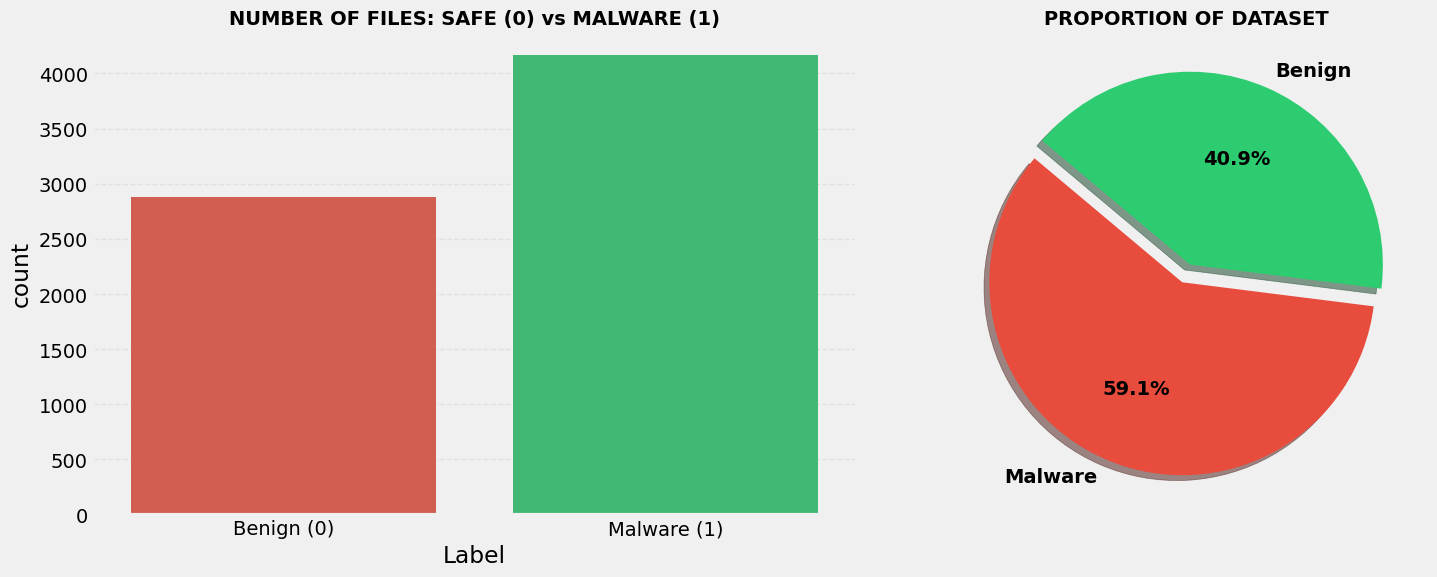

In [ ]:
# --- 2. LABEL DISTRIBUTION ---
# Color definiton
custom_colors = {
    0: '#2ecc71',  # Green (Safe)
    1: '#e74c3c'   # Red (Malicious)
}

# Calculate the counts
label_counts = df['Label'].value_counts().reset_index()
label_counts.columns = ['Label', 'count']

# Create a color list
palette_list = [custom_colors.get(l, '#95a5a6') for l in label_counts['Label']]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
sns.barplot(x='Label', y='count', data=label_counts, ax=ax[0], palette=palette_list, hue='Label', legend=False)
ax[0].set_title('NUMBER OF FILES: SAFE (0) vs MALWARE (1)', fontsize=14, fontweight='bold')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Benign (0)', 'Malware (1)'])
ax[0].grid(axis='y', linestyle='--', alpha=0.4)

# Pie chart
ax[1].pie(
    label_counts['count'], 
    labels=['Malware' if l==1 else 'Benign' for l in label_counts['Label']],
    autopct='%1.1f%%', 
    startangle=140,
    shadow=True, 
    explode=[0.05, 0.05],
    colors=palette_list,
    textprops={'fontweight': 'bold'}
)
ax[1].set_title('PROPORTION OF DATASET', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Importance & Ranking

Not all features in a Portable Executable (PE) file are equally useful for detecting malware. Some might be redundant, while others (like entropy or specific header flags) are "smoking guns."

### 🧠 What is Mutual Information (MI)?
Unlike standard correlation, **Mutual Information** measures the reduction in uncertainty for the target variable (`Label`) given the value of a feature. 
* **High Score:** The feature provides significant information to distinguish between Malware and Benign files.
* **Low Score:** The feature is likely "noise" and can be dropped to simplify the model and prevent overfitting.

### 🛠️ Process:
1. **Data Sanitization:** Remove non-predictive identifiers like `MD5` hashes.
2. **Information Gain Calculation:** Use `mutual_info_classif` to quantify the dependency.
3. **Visualization:** Rank features from most to least impactful.

C:\Users\vppho\AppData\Local\Temp\ipykernel_24264\2835626866.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma')
C:\Users\vppho\AppData\Local\Temp\ipykernel_24264\2835626866.py:25: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vppho\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


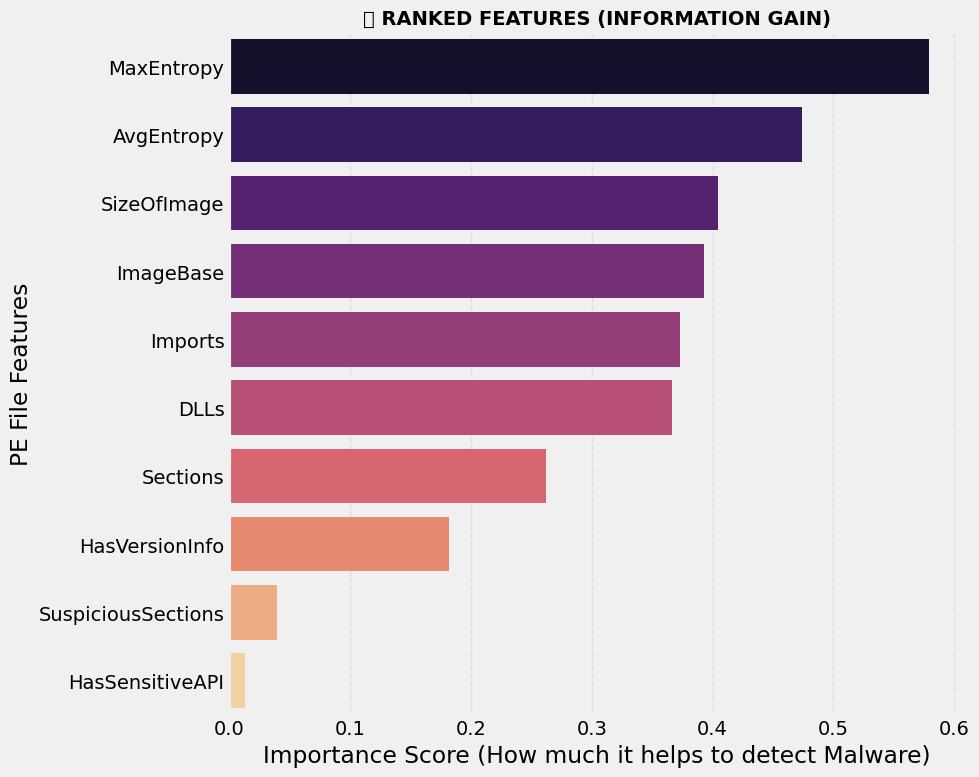

In [ ]:
# --- 3. RANKED FEATURES (Mutual Information) ---
# 1. Prepare the data
# Drop MD5 (id) & Label (target)
X_eda = df.drop(['MD5', 'Label'], axis=1)
y_eda = df['Label']

# 2. Calculate Mutual Information (Information Gain)
importances = mutual_info_classif(X_eda, y_eda, random_state=42)

# 3. Create a result table
mi_df = pd.DataFrame({
    'Feature': X_eda.columns,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

# 4. Plot Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma')

plt.title('🏆 RANKED FEATURES (INFORMATION GAIN)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (How much it helps to detect Malware)')
plt.ylabel('PE File Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Feature Polarization: Benign vs. Malware Strength

While Mutual Information tells us **which** features are important, it doesn't tell us **how** they characterize the file. In this section, we analyze the "Strength Difference" to identify which features are hallmarks of Malware versus those typical of Benign software.

### 🔍 Methodology:
1. **Grouped Means:** We calculate the average value for every feature, grouped by their class (`Label`).
2. **Min-Max Normalization:** Since features have different scales (e.g., file size in bytes vs. section counts), we normalize them to a $[0, 1]$ range for a fair comparison.
3. **Strength Calculation:** $$\text{Strength} = \text{Mean}_{\text{Benign}} - \text{Mean}_{\text{Malware}}$$
   * **Positive Score (<span style="color:#2ecc71">Green</span>):** Feature is more prominent in **Safe** files.
   * **Negative Score (<span style="color:#e74c3c">Red</span>):** Feature is a signature characteristic of **Malware**.

> **Insight:** This visualization helps us build a "profile" for malware, allowing us to see at a glance which technical attributes (like high entropy or specific flags) drive a "Malicious" verdict.

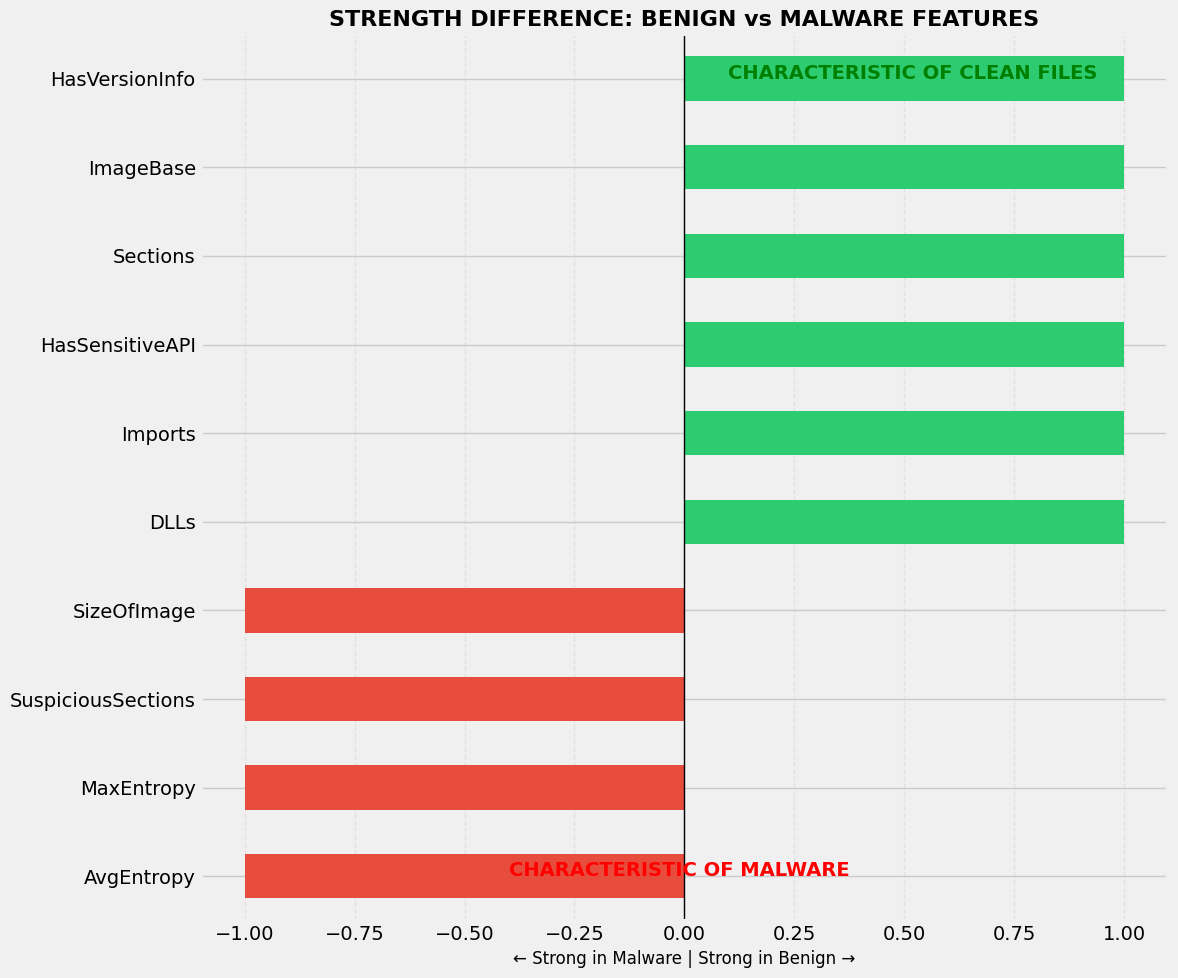

In [ ]:
# --- 4. STRENGTH DIFFERENCE (BENIGN vs MALWARE) ---
# Calculate the difference between BENIGN & MALWARE files
summary = df.drop('MD5', axis=1).groupby('Label').mean()

# Normalization to compare features
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())

# BENIGN SCORE: Positive means BENIGN features, NEGATIVE means MALWARE features
# Benign Power = (mean value of Benign) - (mean value of Malware)
benign_power = (summary_norm.loc[0] - summary_norm.loc[1]).sort_values()

# Create horizontal bar chart
plt.figure(figsize=(12, 10))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in benign_power]
benign_power.plot(kind='barh', color=colors)

# Arrange to clearly show Strong/Weak
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('STRENGTH DIFFERENCE: BENIGN vs MALWARE FEATURES', fontsize=16, fontweight='bold')
plt.xlabel('← Strong in Malware | Strong in Benign →', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Add text annotations
plt.text(0.1, len(benign_power)-1, 'CHARACTERISTIC OF CLEAN FILES', color='green', fontweight='bold')
plt.text(-0.4, 0, 'CHARACTERISTIC OF MALWARE', color='red', fontweight='bold')

plt.tight_layout()
plt.show()